## 1. Interactive Precharge Calculator

### Purpose
Calculate the required precharge flux and duration for each LED configuration to achieve optimal conditioning.

### How to Use:
1. **Select Side**: A or B
2. **Enter Target Flux**: The science flux level you plan to use (e⁻/pix/s)
3. **Enter Precharge Duration**: How long you want to precharge (seconds, typically 30s)
4. **Click Submit**: Get precharge settings for all LEDs

### Precharge Constants (pc dictionary)
These values are empirically determined charge factors for each band:
- **Band 4 (1300nm)**: 2164 mA·s/mA (both sides)
- **Band 5 (1550nm)**: 1633 (Side A), 1300 (Side B) mA·s/mA
- **Band 6 (1750nm)**: 1040 mA·s/mA (both sides)

### Output Format
For each LED, you'll get: `LED{bank}{band} PRECHARGE_FLUX = X.X e-/pix/s PRECHARGE_TIME=Xs then Y e-/pix/s`

This tells you to run the LED at X.X flux for X seconds before switching to your target flux Y.

In [1]:
import pandas as pd
import numpy as np
from srcs_utils import *
import ipywidgets as widgets
from IPython.display import display


def print_precharge(side, target_flux, precharge_duration):
    pc = dict()
    if side == 'A':
        pc[4] = 2164
        pc[5] = 1633
        pc[6] = 1040
    else:
        pc[4] = 2164
        pc[5] = 1300
        pc[6] = 1040

    a = 0
    for t in [target_flux]:
        for band in [4, 5, 6]:
            for bank in [1, 2]:
                fc = flux_to_current(side, band, bank, t, raise_corner_case=False)*1e3
                ct = precharge_duration
                precharge_current = fc*pc[band]/ct
                if current_to_hex(side, bank, precharge_current/1e3) > (2*65535 - 1):
                    box = 1 if side.upper() == 'A' else 2
                    f = ftoc[(ftoc.band == band) & (ftoc.box == box) & (ftoc.bank == bank)].iloc[0]
                    precharge_flux = f['high max flux\n[e-/pix/s]'] - 2
                    precharge_current = flux_to_current(side, band, bank, precharge_flux, raise_corner_case=False)*1e3
                    ct = fc*pc[band]/precharge_current

                flux_pc = current_to_flux(side, band, bank, precharge_current/1e3)

                print(f'LED{bank}{band} PRECHARGE_FLUX = {flux_pc:.1f} e-/pix/s PRECHARGE_TIME={ct:.0f}s then {t} e-/pix/s')

    print('')
    print('')


side_dropdown = widgets.Dropdown(
    options=['A', 'B'],
    value='B',
    description='Side:'
)

target_flux_box = widgets.FloatText(
    value=500.0,
    description='Target Flux:',
    step=0.1
)

precharge_duration_box = widgets.FloatText(
    value=30.0,
    description='Precharge Duration:',
    step=0.1
)

submit_button = widgets.Button(
    description='Submit',
    button_style='success',
    tooltip='Click to calculate precharge values'
)

output = widgets.Output()

def on_submit_clicked(b):
    with output:
        output.clear_output()
        print_precharge(side_dropdown.value, target_flux_box.value, precharge_duration_box.value)

submit_button.on_click(on_submit_clicked)
display(side_dropdown, target_flux_box, precharge_duration_box, submit_button, output)


Dropdown(description='Side:', index=1, options=('A', 'B'), value='B')

FloatText(value=500.0, description='Target Flux:', step=0.1)

FloatText(value=30.0, description='Precharge Duration:', step=0.1)

Button(button_style='success', description='Submit', style=ButtonStyle(), tooltip='Click to calculate precharg…

Output()


## 2. Precharge Data Processing

### Purpose
Process LED performance data from test campaigns to calculate settling metrics and evaluate precharge effectiveness.

### Data Flow
1. **Load**: Read parquet files from `data/precharge/` directory
2. **Detect**: Identify LED on/off transitions and configuration changes
3. **Calculate**: Compute settling metrics (60to300) for each LED state
4. **Track**: Monitor precharge history (current and duration)
5. **Export**: Save metrics to HDF5 and generate PowerPoint plots

### Key Processing Parameters
- **foi (flux of interest)**: [0.3, 60] e⁻/pix/s - Low and high flux conditions
- **boi (band of interest)**: [4, 5, 6] - Spectral bands to analyze
- **bankofint**: [1, 2] - LED banks
- **norm_to**: 299 seconds - Normalization point for settling calculation
- **p**: 1 (Photodiode 1 - primary detector)

### Output Metrics
The `m` dataframe contains:
- **60to300**: Primary settling metric [%]
- **precharge [s]**: Duration of previous high-current operation [s]
- **precharge [mA]**: Current level during precharge [mA]
- **precharge [mA*s]**: Total charge delivered [mA·s]
- **mA*s/final_mA**: Normalized precharge factor
- **flux**: Operating flux level [e⁻/pix/s]
- **band, bank, side**: LED configuration identifiers
- **setname**: Test campaign identifier
- **PD1 data, PD2 data**: Raw photodiode measurements

### Processing Time
- **Reprocess data**: ~5 minutes (analyzes all raw parquet files)
- **Load existing data**: < 1 second (loads pre-calculated metrics)

### Recommendation
**First time users**: Select "Load existing data" to explore results quickly, then reprocess if needed.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from glob import glob
from tqdm import tqdm
from os.path import basename
from scipy.io import loadmat
from srcs_utils import *
import analysis_export_utils as ex
import ipywidgets as widgets
from IPython.display import display, clear_output
import os
%matplotlib widget
plt.rcParams.update({'figure.max_open_warning': 50})

m = None

def reprocess_data():
    global m
    dataset = dict()

    from glob import glob
    for f in glob('data/precharge/*.parquet'):
        k = f.replace('.parquet', '')
        if ('chargeup' in k) or ('precharge' in k.lower()):
            dataset[basename(k)] = pd.read_parquet(f)



    aside_pc = [k for k in dataset.keys() if k.startswith('A')]


    percent = True
    ex.create_ppt("templates/rst_scipa.pptx")
    metrics = list()
    norm_to = 299
    prebank = 0
    preband = 0
    precharget = 0
    prechargec = 0
    plt.close('all')
    p = 1
    for foi in [0.3, 60]:
        for boi in [4, 5, 6]:
            #plt.figure()
            for bankofint in [1, 2]:

                fig = plt.figure(dpi=130)
                fig.set_size_inches(w=10, h=6.25)

                for k in dataset.keys():
                    df = dataset[k]
                    print(k)
                    side = k[0]

                    allinfo = list()
                    darkv = get_wfi_darkv(df, legacy=True)
                    print(darkv)

                    anyc, oniloc = process_wfi_changes(df)
                    anyc = anyc.ffill()
                    this_set = dict()

                    for i in range(len(anyc)):
                        st = anyc.index[i]
                        if i >= len(anyc.index) - 1:
                            en = anyc.index[-1]
                        else:
                            en = anyc.index[i+1]

                        data = df.loc[(st+pd.Timedelta(seconds=1)):(en - pd.Timedelta(seconds=0))]
                        if (len(data) > 15) and (anyc.iloc[i].on):

                            info = get_info_wfi(data, side=side, cfg=anyc.iloc[i])
                            band = info['band']
                            bank = info['bank']
                            cur = info['current']
                            code = info['code']
                            if not ((prebank == bank) and (preband == band)):
                                precharget = 0
                                prechargec = 0

                            #if (info['bank'] == b and (info['code'] == c) and (info['band']  == 4)):
                            if (len(data) > 15) and (band != 0):
                                #print(f'{k}:side={side}, band={band}, bank={bank}, code={code}')
                                flux = code_to_flux(side, band, bank, code)

                                if flux < 10:
                                    flux = round(flux, 1)
                                else:
                                    flux = round(flux, 0)

                                #print(flux)
                                ledinfo = f'Side{side}|Band{band}|Bank{bank}@{flux}for{code}[{i}]{darkv[1]:.5f}'
                                #print(ledinfo)
                                if (bank == bankofint) & (band == boi) and (flux == foi) and (prechargec >= 0):#5284
                                    pc_fma = prechargec*precharget/(info['current']*1e3)
                                    old_label = f'{k[-2:]} [{pc_fma:.0f}mA*s/fmA]'
                                    print(k)
                                    label = f'Side{side}[@{flux:.0f}e-/pix/s|{cur*1e3:.2f}mA|{pc_fma:.0f}mA/fmA]'
                                    metric,pd1,pd2,fv1,fv2 = metric_calc_wfi(data, darkv, p, '', label, info=info, norm_to=norm_to, side=side, plot=True, percent=percent, rolling=0)
                                    for key,val in info.items():
                                        metric[key] = val
                                    metric['setname'] = k
                                    metric['precharge [s]'] = precharget
                                    metric['precharge [mA]'] = prechargec
                                    metric['precharge [mA*s]'] = prechargec*precharget
                                    metric['mA*s/final_mA'] = pc_fma
                                    metric['flux'] = flux
                                    metric['pd'] = p
                                    metric['PD1 data'] = pd1
                                    metric['PD2 data'] = pd2
                                    metric['fv1'] = fv1
                                    metric['fv2'] = fv2
                                    metrics.append(metric)
                                lastt = (data.index[-1] - data.index[0]).total_seconds()
                                precharget = lastt
                                prechargec = info['current']*1e3
                                prebank = bank
                                preband = band

                        elif (not anyc.iloc[i].on) and (len(data) > 6):
                            #print('alternate dark found')
                            # the drift is so small that this doesn't make a big difference
                            darkv = get_wfi_darkv(data, legacy=True)

                plt.legend()

                if foi > 1000:
                    plt.ylim([-.1, .05])
                elif foi == 60:
                    plt.ylim([None, .5])
                else:
                    plt.ylim([-2, 2])


                plt.ylabel(f'LED Settling [%]')
                plt.xlabel('Time [seconds]')
                plt.grid(True)
                plt.gcf().set_tight_layout(True)
                ex.add_figure(title=f'Band {boi} Bank {bankofint} PD{p}@ {foi} e-/pix/s', xd=10, yd=6.25, x0=1.67, y0=1)

                #plt.close()

        m = pd.DataFrame(metrics)

        save_dropdown = widgets.Dropdown(
            options=['Yes', 'No'],
            value='No',
            description='Save metrics?',
            disabled=False,
        )
        save_button = widgets.Button(description="Confirm")
        save_output = widgets.Output()

        def on_save_button_clicked(b):
            with save_output:
                clear_output()
                if save_dropdown.value == 'Yes':
                    m.to_hdf('data/precharge/metrics.h5', key='metrics', mode='w')
                    print("Metrics saved to data/precharge/metrics.h5")
                else:
                    print("Metrics not saved")
                display(m)

        save_button.on_click(on_save_button_clicked)
        display(save_dropdown, save_button, save_output)

def load_existing_data():
    global m
    m = pd.read_hdf('data/precharge/metrics.h5', key='metrics')
    print("Metrics loaded from data/precharge/metrics/metrics.h5")
    display(m)

dropdown = widgets.Dropdown(
    options=['Reprocess data', 'Load existing data'],
    value='Load existing data',
    description='Action:',
    disabled=False,
)

button = widgets.Button(description="Execute")
output = widgets.Output()

def on_button_clicked(b):
    with output:
        clear_output()
        if dropdown.value == 'Reprocess data':
            reprocess_data()
        else:
            load_existing_data()

button.on_click(on_button_clicked)

display(dropdown, button, output)

Dropdown(description='Action:', index=1, options=('Reprocess data', 'Load existing data'), value='Load existin…

Button(description='Execute', style=ButtonStyle())

Output()

## Below are some example tables that can be generated for understanding the data

In [4]:
m[m.side == 'A'][['time', 'setname', 'band', 'bank', 'pd1', '60to300', 'mA*s/final_mA', 'flux', 'seconds']]

,time,setname,band,bank,pd1,60to300,mA*s/final_mA,flux,seconds
0,2025-08-20 12:43:19.601196051,A STV 200K Precharge r1,4,1,0.000148,0.6024,1656.226048,0.3,313.981913
1,2025-08-20 15:24:55.033910036,A STV 200K Precharge r2,4,1,0.000167,0.3565,2152.526489,0.3,314.981332
2,2025-08-20 19:24:55.169235945,A STV 200K Precharge r4,4,1,0.000187,1.1173,832.758207,0.3,313.980978
7,2025-08-20 12:48:43.582535028,A STV 200K Precharge r1,4,2,0.000122,6.3570,0.000000,0.3,346.980010
8,2025-08-20 15:30:53.012691975,A STV 200K Precharge r2,4,2,0.000144,1.2410,2161.016309,0.3,313.981308
...,...,...,...,...,...,...,...,...,...
169,2025-08-20 13:48:47.373673916,A STV 200K Precharge r1,6,2,0.001482,0.0402,799.519943,60.0,311.981786
170,2025-08-20 15:18:57.055138111,A STV 200K Precharge r2,6,2,0.001491,0.1799,0.000000,60.0,314.981319
171,2025-08-20 16:30:17.800612926,A STV 200K Precharge r2,6,2,0.001491,-0.0200,1074.430711,60.0,314.981178
172,2025-08-20 18:05:57.455719948,A STV 200K Precharge r3,6,2,0.001497,-0.1394,1351.513352,60.0,314.980975


In [5]:
m[(m.side == 'A') & (m.band == 5)][['time', 'setname', 'band', 'bank', 'pd1', '60to300', 'mA*s/final_mA', 'flux', 'seconds']]

,time,setname,band,bank,pd1,60to300,mA*s/final_mA,flux,seconds
14,2025-08-20 12:55:13.560096979,A STV 200K Precharge r1,5,1,0.000059,0.0000,998.233341,0.3,312.981916
15,2025-08-20 15:36:49.991447926,A STV 200K Precharge r2,5,1,0.000064,0.0000,1299.042885,0.3,313.981398
16,2025-08-20 19:36:47.126065016,A STV 200K Precharge r4,5,1,0.000066,-1.3636,499.400793,0.3,313.980931
21,2025-08-20 13:00:36.541435957,A STV 200K Precharge r1,5,2,0.000058,0.5168,0.000000,0.3,346.979986
22,2025-08-20 15:42:13.972240925,A STV 200K Precharge r2,5,2,0.000062,-2.3923,0.000000,0.3,345.979483
23,2025-08-20 19:42:12.106308937,A STV 200K Precharge r4,5,2,0.000064,-3.7209,0.000000,0.3,345.978976
92,2025-08-20 04:27:06.181175947,A STV 200K chargeup,5,1,0.008555,1.1489,0.000000,60.0,313.985059
93,2025-08-20 06:32:41.810690880,A STV 200K chargeup,5,1,0.009185,0.5352,0.000000,60.0,298.984858
94,2025-08-20 12:21:11.677324057,A STV 200K Precharge r1,5,1,0.009117,0.6666,0.000000,60.0,313.982002
95,2025-08-20 13:30:57.435988903,A STV 200K Precharge r1,5,1,0.009173,0.2014,999.599512,60.0,314.981678


In [14]:
m['fv1']

KeyError: 'fv1'

## 3. Precharge Mapping Plots

### Purpose
Generate detailed plots showing the relationship between precharge factors and LED settling behavior.

### Analysis Approach
- **X-axis**: `mA*s/final_mA` - Normalized precharge factor
- **Y-axis**: `60to300` - Settling metric (% change from 60s to 300s)
- **Goal**: Visualize how precharge amount affects stability across different LED configurations

### Visualization Strategy
- **Separate plots** for each band and flux level
- **Color-coded** by bank and flux
- **Markers**: Circles (○) for Bank 1, Triangles (△) for Bank 2
- **Reference lines**: ±0.1% (red dashed) shows optimal stability zone

### Output
- PowerPoint presentation with all precharge characterization plots
- Filename: `WFITV2_cold_side{A/B}_precharge.pptx`


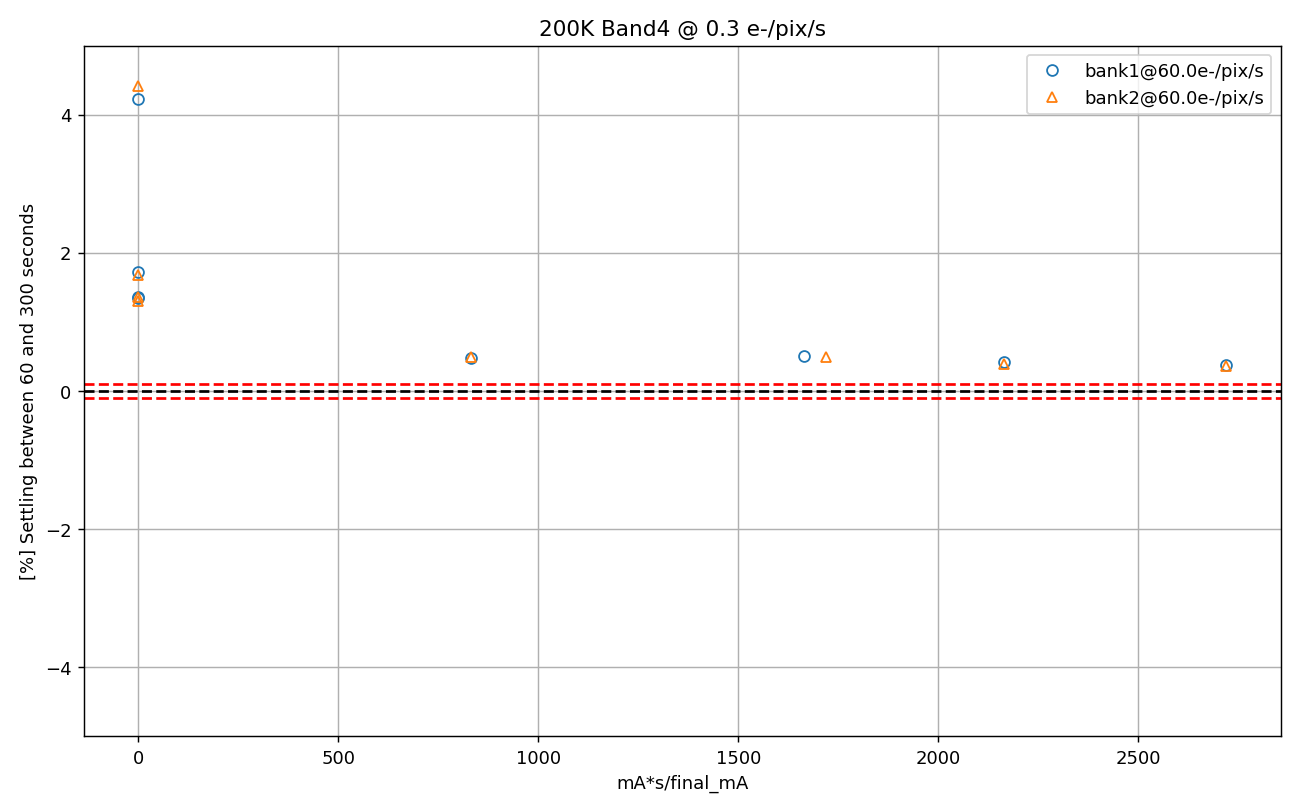

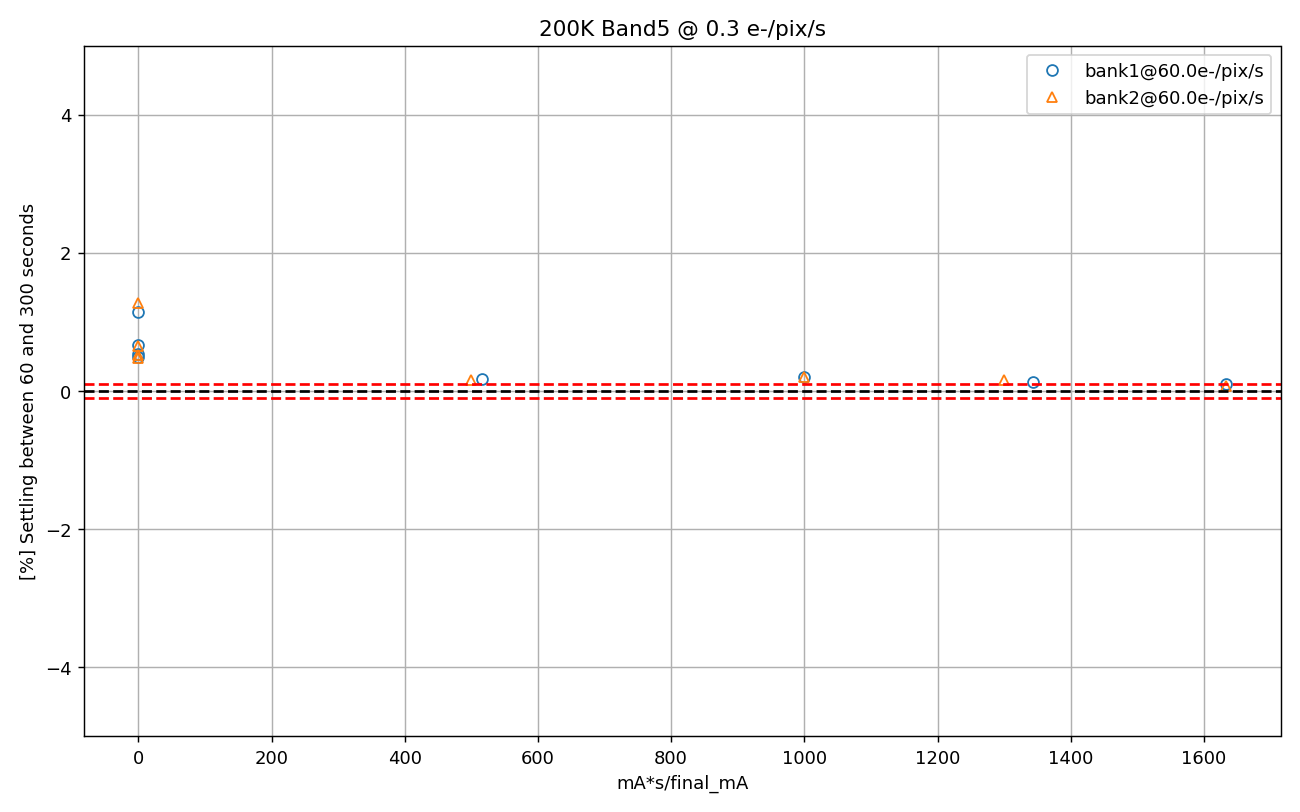

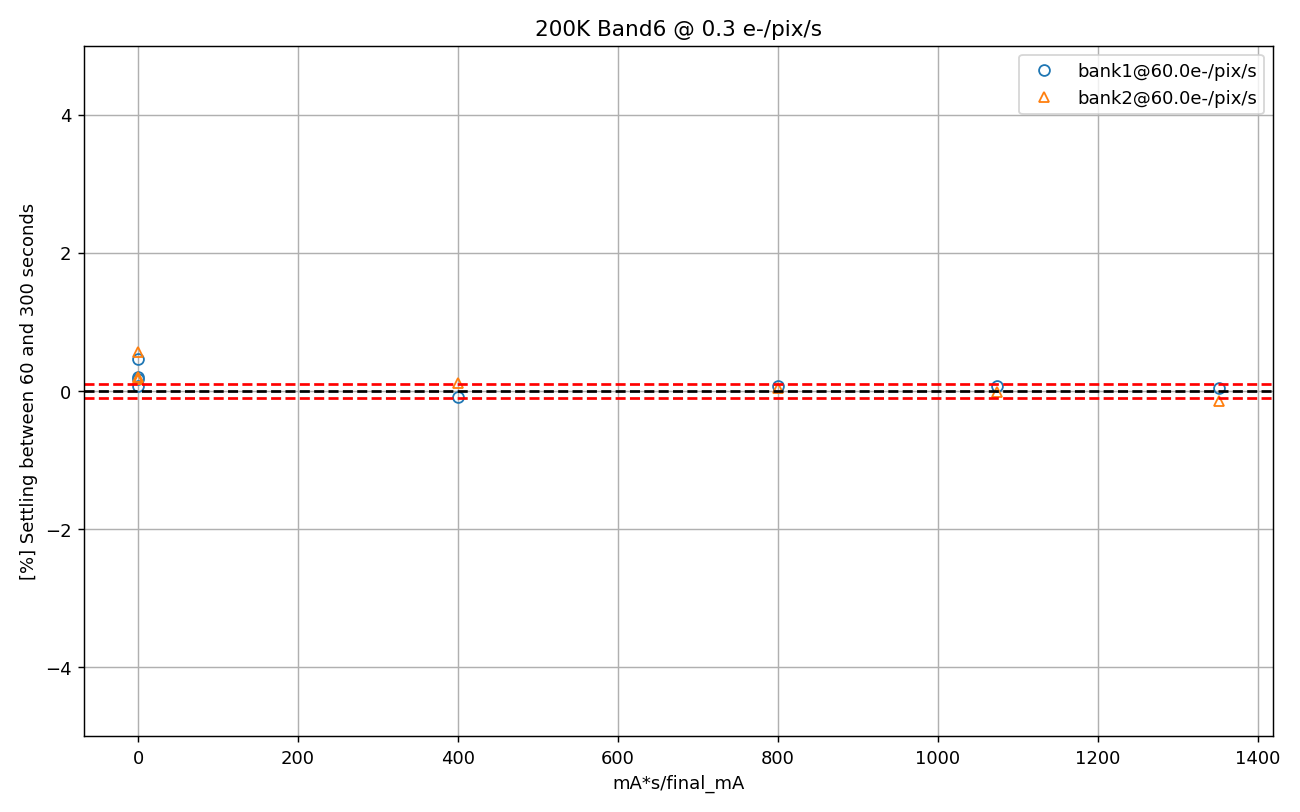

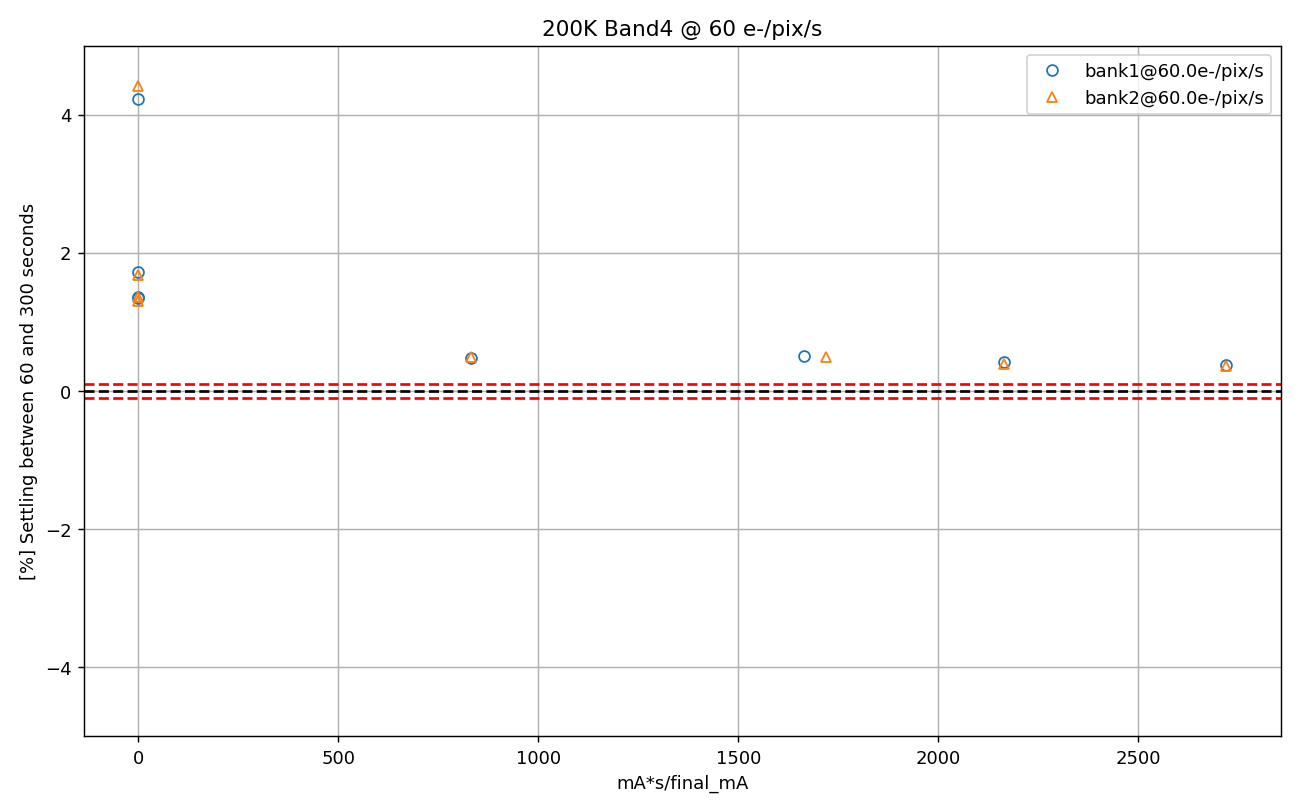

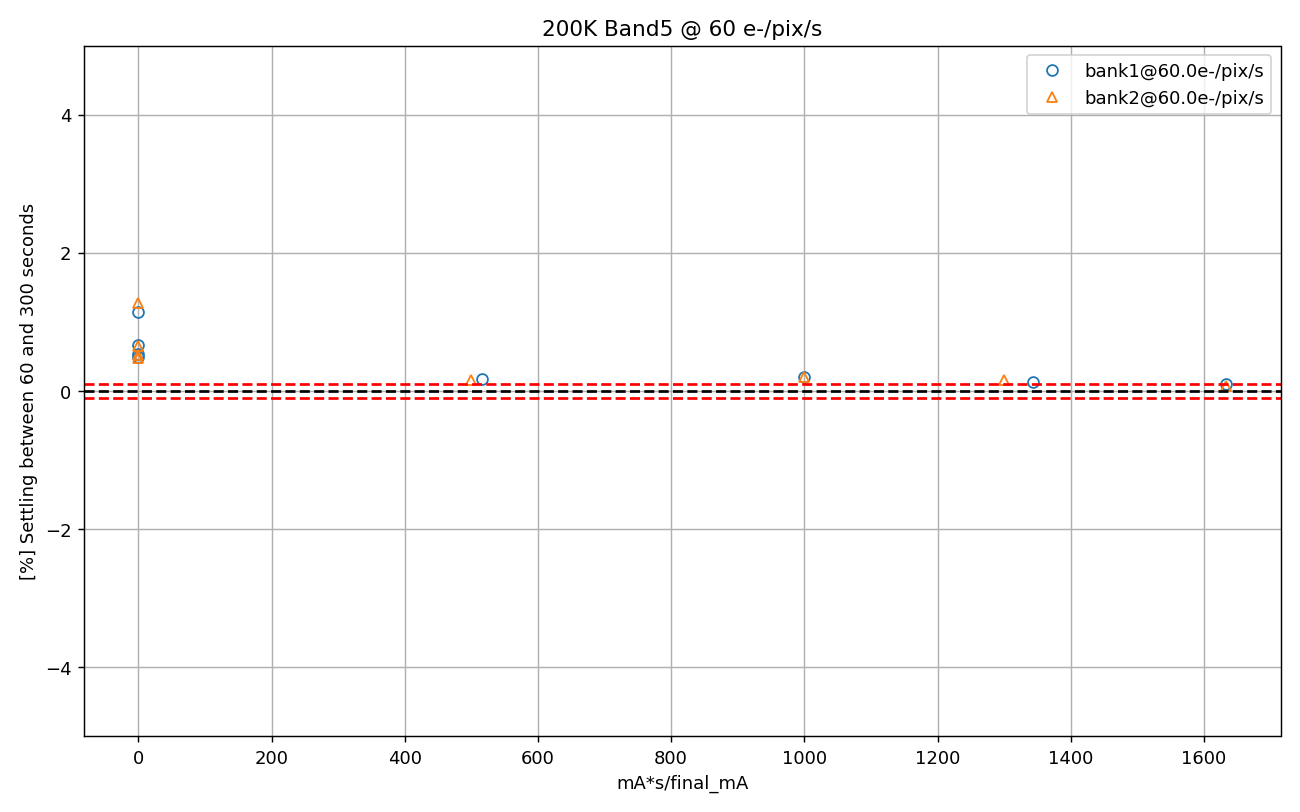

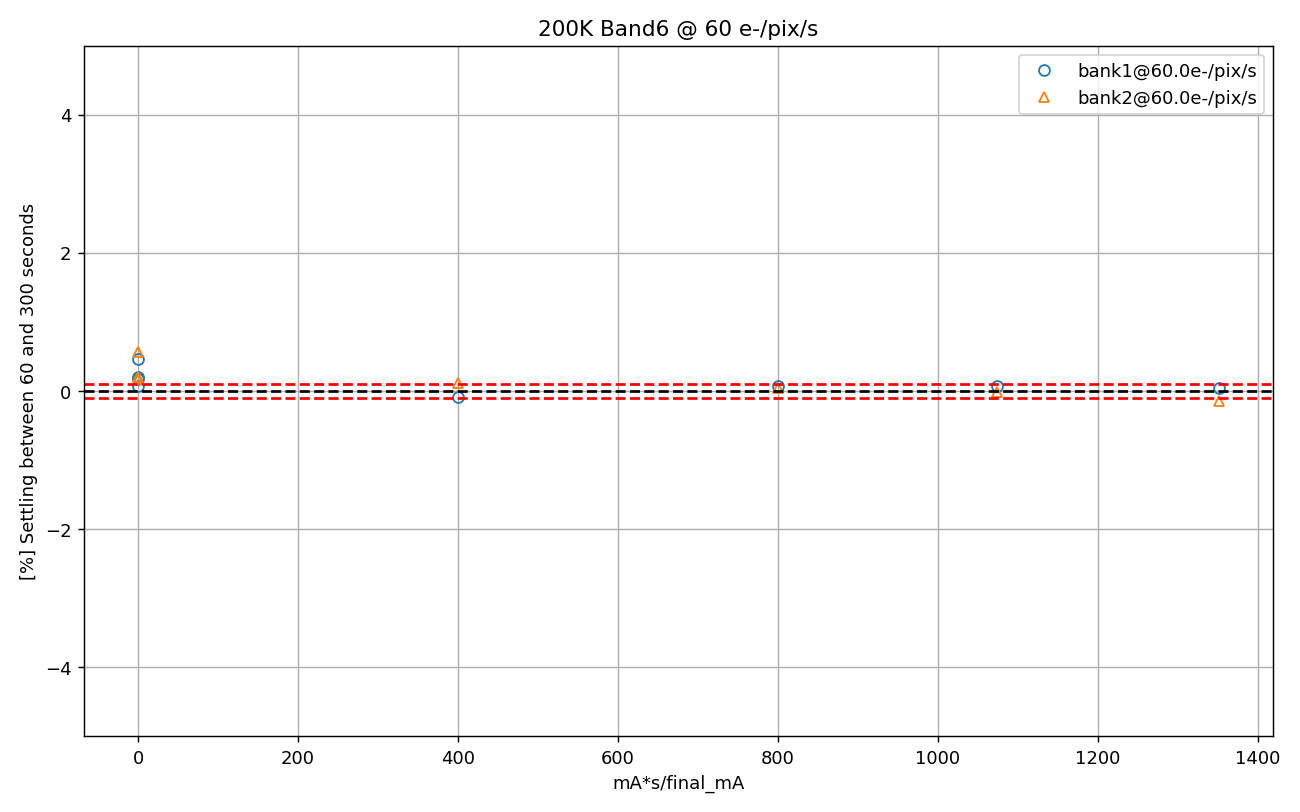

In [8]:

from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline

plt.close('all')
xp ='mA*s/final_mA'
yp ='60to300'
side = 'A'

ex.create_ppt('templates/rst_scipa.pptx')
#log_func = lambda t,a,b, c: a+b*np.log(t*c)
def log_func(x, a, b, c):
    return a * np.log(b + x) + c
def exp_func(t, A, K, C):
    return A * np.exp(K * t) + C

for foi in [0.3, 60]:
    mf = m[(m.flux == 60) & (m.side == side)].copy()
    mf = mf[mf.time > pd.Timestamp('2024-04-01')]

    for band in [4, 5, 6]:
        fig = plt.figure(dpi=130)
        fig.set_size_inches(w=10, h=6.25)
        plt.title(f'200K Band{band} @ {foi} e-/pix/s')
        ax = plt.gca()
        #ax2 = ax.twinx()
        for bank in [1, 2]:

            d = mf[(mf.band == band) & (mf.bank == bank) & (mf['precharge [mA]'] >= 0)].sort_values(by=xp)#.plot(x='mA*s/final_mA', y='60to300', ax=ax, label=f'bank{bank}', marker='.', linestyle='none')
            for c,v in d.groupby('flux'):

                x = v[xp]
                y = v[yp]
                lines = v.plot(xp, yp, label=f'bank{bank}@{c}e-/pix/s', marker= 'o' if bank == 1 else '^', markerfacecolor='none', linestyle='none', ax=ax).lines
                # mA*s/final_mA precharge [mA*s]
                #fit,cov = curve_fit(exp_func, x, y, bounds=(-np.inf, np.inf))
                #fit = np.poly1d(np.polyfit(x, y, deg=2))
                #fit = UnivariateSpline(x, y, k=2)
                #lines = n.plot(x=xp, y=yp, linestyle='none', marker='.', label=label, ax=ax).lines
                xf = np.linspace(x.min(), x.max(), 1000)
                #decay_model2(t1, *fp12)
                #plt.plot(xf, log_func(xf, *fit), '--', label='_hide', color=lines[-1].get_color())
                #plt.plot(xf, fit(xf), '--', label='_hide', color=lines[-1].get_color())
        plt.ylabel('[%] Settling between 60 and 300 seconds')
        plt.axhline(y=.1, color='red', linestyle='dashed')
        plt.axhline(y=-.1, color='red', linestyle='dashed')
        plt.axhline(y=0, linestyle='dashed', color='black')
        plt.ylim([-5, 5])
        plt.grid(True)
        plt.gcf().set_tight_layout(True)
        ex.add_figure(title=f'Band {band} PD2 Metrics@ {foi} e-/pix/s', xd=10, yd=6.25, x0=1.67, y0=1)
ex.save_ppt(f'WFITV2_cold_side{side}_precharge.pptx')

## 4. Visualizing Settling Performance Zones

### Purpose
Generate plots showing the relationship between precharge factor and LED settling performance with color-coded stability zones.

### Visualization Features
- **X-axis**: mA*s/final_mA - Normalized precharge factor
- **Y-axis**: 60to300 - Settling metric (% change from 60s to 300s)
- **Color zones**:
  - **Green** (<0.1%): Excellent stability - meets science requirements
  - **Orange** (0.1-1%): Marginal stability - acceptable for some applications
  - **Red** (>1%): Poor stability - requires better precharge
- **Markers**: Different symbols for each bank (○ = Bank 1, △ = Bank 2)

### Analysis Value
These plots allow easy identification of:
- Minimum precharge factor needed for optimal stability
- Differences between LED banks within the same band
- Wavelength-dependent precharge requirements

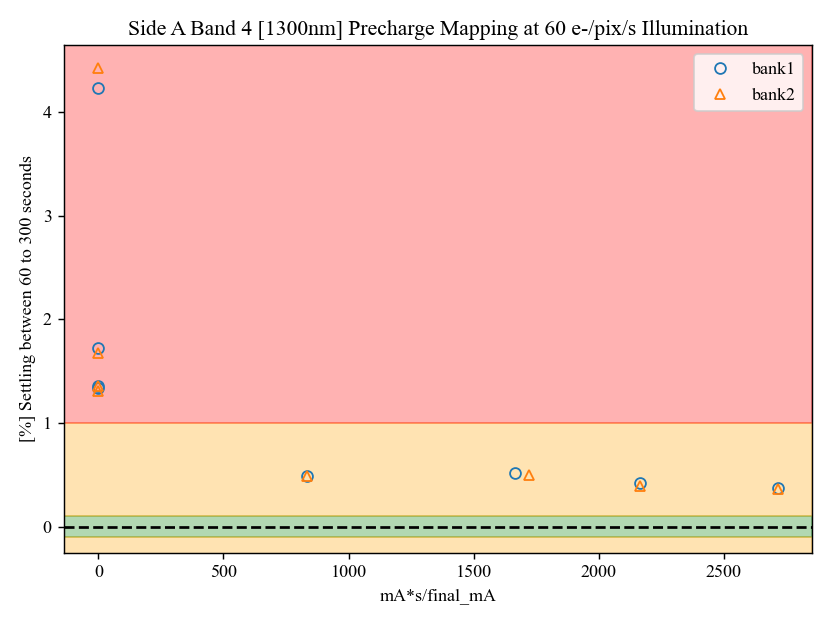

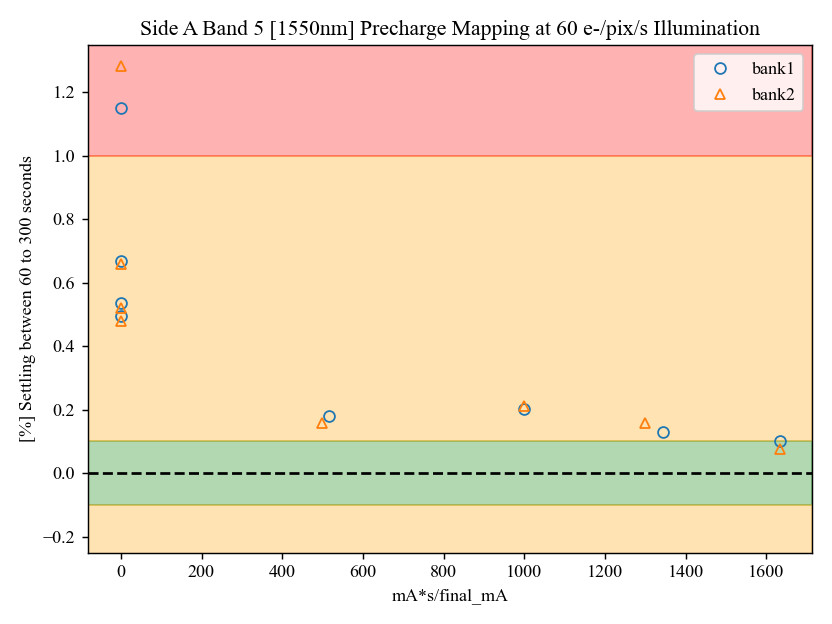

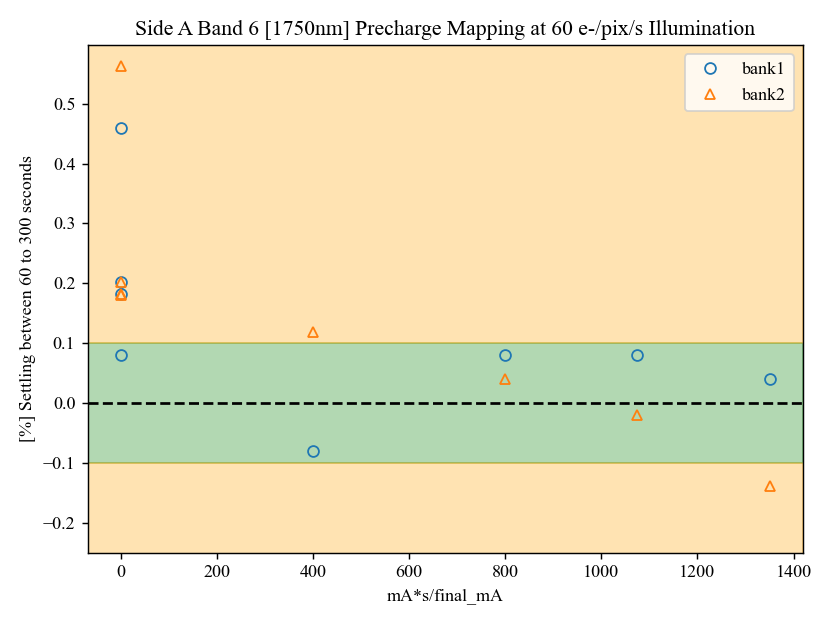

In [13]:
side = 'A'
mf = m[(m.flux == 60) & (m.side == side)].copy()
mf = mf[mf.time > pd.Timestamp('2024-04-01')]
plt.close('all')
band_map = {1:'625nm', 2:'880nm', 3:'1070nm', 4:'1300nm', 5:'1550nm', 6:'1750nm'}
for band in [4, 5, 6]:
    fig = plt.figure(dpi=130)
    wv = band_map[band]
    plt.title(f'Side {side} Band {band} [{wv}] Precharge Mapping at 60 e-/pix/s Illumination')
    ax = plt.gca()
    #ax2 = ax.twinx()
    for bank in [1, 2]:
        #m[(m.band == 4) & (m.bank == bank) & (m.flux == 60)].plot(x='time', y='pd2', ax=ax, label=f'bank{bank}', marker='.')
        #m[(m.band == 4) & (m.bank == bank) & (m.flux == 60)].plot(x='time', y='board', ax=ax2, label=f'bank{bank}', linestyle='dashed')
        marker ='o' if bank == 1 else '^'
        mf[(mf.band == band) & (mf.bank == bank) & (mf['precharge [mA]'] >= 0)].plot(x='mA*s/final_mA', y='60to300', ax=ax, label=f'bank{bank}', marker=marker, linestyle='none', markerfacecolor='none')
        #m[(m.band == band) & (m.bank == bank) & (m['precharge [mA]'] > 0)].plot(x='time', y='60to300', ax=ax, label=f'bank{bank}', marker='.', linestyle='none')
    '''
    plt.axhline(y=.1, color='orange', linestyle='dashed')
    plt.axhline(y=-.1, color='orange', linestyle='dashed')
    plt.axhline(y=1, color='red', linestyle='dashed')
    plt.axhline(y=-1, color='red', linestyle='dashed')
    '''
    plt.axhline(y=0, linestyle='dashed', color='black')
    plt.ylim([-.25, None])

    xl = ax.get_xlim()
    yl = ax.get_ylim()
    plt.fill_between(xl, -.1, .1, color='green', alpha=0.3,
                 interpolate=True)
    plt.fill_between(xl, -1, -.1, color='orange', alpha=0.3,
                 interpolate=True)
    plt.fill_between(xl, .1, 1, color='orange', alpha=0.3,
                 interpolate=True)
    plt.fill_between(xl, 1, yl[1], color='red', alpha=0.3,
                 interpolate=True)

    plt.xlim(xl)
    plt.ylim(yl)
    plt.ylabel('[%] Settling between 60 to 300 seconds')

    fig.set_tight_layout(True)
    #plt.xscale('log')

## 5. Time-Series Trending of Settling Without Precharge

### Purpose
Track how LED settling behavior evolves over time when operated **without precharge conditioning**.

### What This Shows
- **Baseline performance**: Settling behavior without any precharge protocol
- **Temporal trends**: Changes across multiple test campaigns
- **Band/Bank variations**: Performance differences between LED configurations at the same time

### Key Parameters
- **Flux level**: 60 e⁻/pix/s (science observation level)
- **Precharge filter**: Only data where `precharge [mA] == 0` (no conditioning)
- **Date range**: After 2024-04-01
- **Y-axis**: 60to300 settling metric [%]

### Interpretation
- **Higher values** = More drift between 60-300s (poor stability)
- **Lower values** = Better inherent stability (less need for precharge)
- **Temporal patterns**: May indicate LED aging, thermal effects, or configuration changes
- **Comparison with Section 4**: Shows improvement achieved by precharge protocols

### Output
- One combined plot showing all bands and banks over time
- Color-coded by band and bank for easy comparison
- Added to PowerPoint export for comprehensive reporting


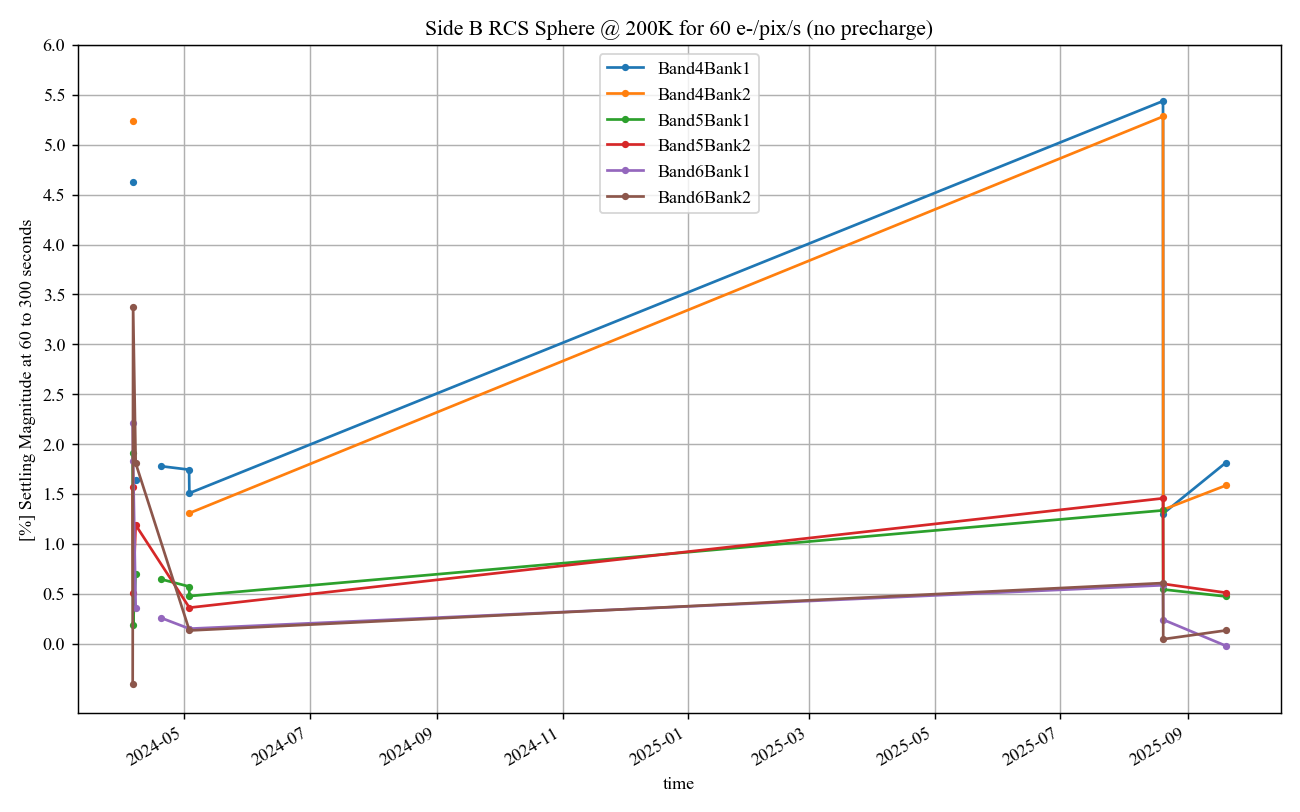

In [12]:
side = 'B'
m['pd2/b'] = m['pd2']/m['board']
mf = m[(m.flux > 0.3) & (m.side == side)].copy()
mf = mf[mf.time > pd.Timestamp('2024-04-01')].sort_values(by='time')
fig = plt.figure(dpi=130)
fig.set_size_inches(w=10, h=6.25)
for band in [4, 5, 6]:

    plt.title(f'Side {side} RCS Sphere @ 200K for 60 e-/pix/s (no precharge)')
    ax = plt.gca()
    for bank in [1, 2]:
        mf[(mf.band == band) & (mf.bank == bank) & (mf.flux == 60)  & (mf['precharge [mA]'] == 0)].plot(x='time', y='60to300', ax=ax, label=f'Band{band}Bank{bank}', marker='.')


ax.set_ylabel('[%] Settling Magnitude at 60 to 300 seconds')
plt.yticks(np.arange(0, 6.1, .5))
plt.grid(True)
fig.set_tight_layout(True)
ex.add_figure(title=f'No Precharge Settling', xd=10, yd=6.25, x0=1.67, y0=1)

## 6. A visualization of precharge settling all bands

/var/folders/0w/vy9t9vf95gbf411s1q3ph0bm0000gp/T/ipykernel_55031/1212456365.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


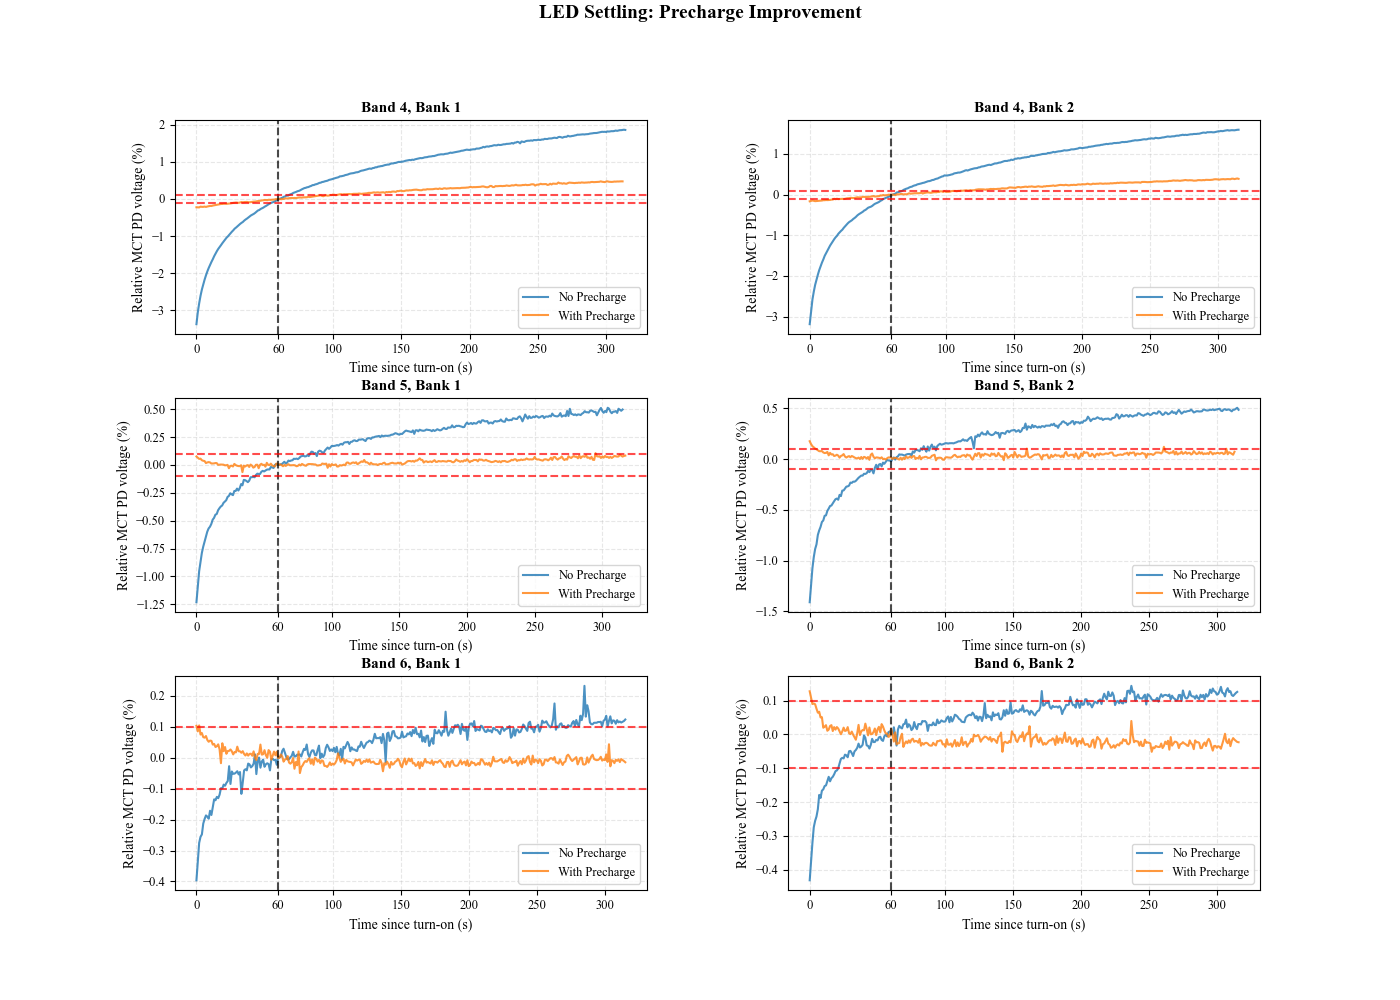

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec
plt.close('all')

fig = plt.figure(figsize=(14, 10))
gs = GridSpec(3, 2, figure=fig, hspace=0.3, wspace=0.3)
side = 'B'
bands = [4, 5, 6]
banks = [1, 2]

plot_idx = 0
for i, band in enumerate(bands):
    for j, bank in enumerate(banks):
       ax = fig.add_subplot(gs[i, j])

       noprecharge_raw = m[(m.band == band) & (m.bank == bank) & (m.side == side) &
                            (m.setname == 'B_STV_200K_Precharge_relaxation_test') &
                            (m['precharge [s]'] == 0)]['pd2 int'].iloc[0]

       precharge_raw = m[(m.band == band) & (m.bank == bank) & (m.side == side) &
                         (m.setname == 'B_STV_200K_Precharge_relaxation_test') &
                         (m['precharge [s]'] > 0)]['pd2 int'].iloc[0]

       noprecharge_df = pd.DataFrame(noprecharge_raw.copy())
       precharge_df =  pd.DataFrame(precharge_raw.copy())

       noprecharge_df['time_rel'] = (noprecharge_df.index - noprecharge_df.index[0]).total_seconds()
       precharge_df['time_rel'] = (precharge_df.index - precharge_df.index[0]).total_seconds()

       noprecharge_baseline = noprecharge_df[noprecharge_df['time_rel'] >= 60]['pd2'].iloc[0]
       precharge_baseline = precharge_df[precharge_df['time_rel'] >= 60]['pd2'].iloc[0]

       noprecharge_df['pd2_rel'] = ((noprecharge_df['pd2'] - noprecharge_baseline) / noprecharge_baseline) * 100
       precharge_df['pd2_rel'] = ((precharge_df['pd2'] - precharge_baseline) / precharge_baseline) * 100

       ax.plot(noprecharge_df['time_rel'], noprecharge_df['pd2_rel'],
               label='No Precharge', linewidth=1.5, alpha=0.8)
       ax.plot(precharge_df['time_rel'], precharge_df['pd2_rel'],
               label='With Precharge', linewidth=1.5, alpha=0.8)

       ax.axvline(x=60, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
       #ax.text(60, ax.get_ylim()[1], '60', ha='center', va='bottom', fontsize=9)
       ax.axhline(y=0.1, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
       #ax.text(ax.get_xlim()[1], 0.1, '+0.1', ha='left', va='center', fontsize=9)
       ax.axhline(y=-0.1, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
       #ax.text(ax.get_xlim()[1], -0.1, '-0.1', ha='left', va='center', fontsize=9)
       #yticks = ax.get_yticks()
       #ax.set_yticks(yticks.tolist() + [-.1, 0.1])
       ax.set_xlabel('Time since turn-on (s)', fontsize=10)
       ax.set_ylabel('Relative MCT PD voltage (%)', fontsize=10)
       ax.set_title(f'Band {band}, Bank {bank}', fontsize=11, fontweight='bold')
       ax.set_xticks([0, 60, 100, 150, 200, 250, 300])
       ax.legend(loc='best', fontsize=9)
       ax.grid(True, alpha=0.3, linestyle='--')
       ax.tick_params(labelsize=9)

plt.suptitle('LED Settling: Precharge Improvement',
            fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


## Precharge plot of just band 5 for paper

KeyError: 'fv1'

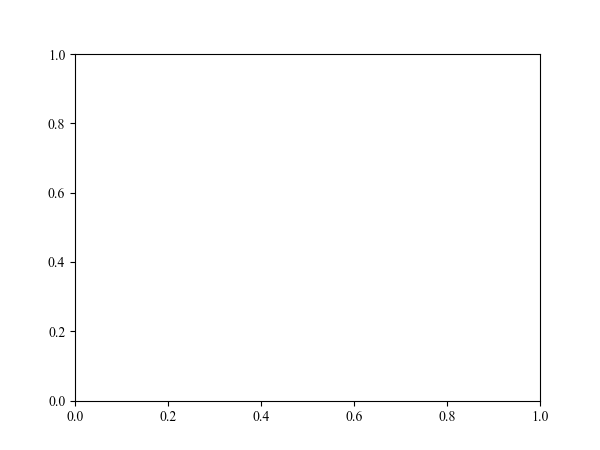

In [11]:
fig = plt.figure(figsize=(6, 4.5))
ax = plt.gca()
side = 'B'
band = 6
bank = 1

#import matplotlib.pyplot as plt
plt.set_cmap('viridis')

plt.rcParams['font.family'] = 'Times New Roman'

# noprecharge_raw = m[(m.band == band) & (m.bank == bank) & (m.side == side) &
#                     (m.setname == 'B_STV_200K_Precharge_relaxation_test') &
#                     (m['precharge [s]'] == 0)]

# # noprecharge_raw_fv = m[(m.band == band) & (m.bank == bank) & (m.side == side) &
# #                     (m.setname == 'B_STV_200K_Precharge_relaxation_test') &
# #                     (m['precharge [s]'] == 0)]['ledfv'].iloc[0]

# precharge_raw = m[(m.band == band) & (m.bank == bank) & (m.side == side) &
#                     (m.setname == 'B_STV_200K_Precharge_relaxation_test') &
#                     (m['precharge [s]'] > 0)]

# # precharge_raw_fv = m[(m.band == band) & (m.bank == bank) & (m.side == side) &
# #                     (m.setname == 'B_STV_200K_Precharge_relaxation_test') &
# #                     (m['precharge [s]']  > 0)]['ledfv'].iloc[0]


# noprecharge_df = pd.DataFrame(noprecharge_raw.copy()).set_index('time')
# precharge_df =  pd.DataFrame(precharge_raw.copy()).set_index('time')

# noprecharge_df['time_rel'] = (noprecharge_df.index - noprecharge_df.index[0]).total_seconds()
# precharge_df['time_rel'] = (precharge_df.index - precharge_df.index[0]).total_seconds()

# noprecharge_baseline = noprecharge_df[noprecharge_df['time_rel'] >= 60]['pd2']
# precharge_baseline = precharge_df[precharge_df['time_rel'] >= 60]['pd2']

# noprecharge_df['pd2_rel'] = ((noprecharge_df['pd2'] - noprecharge_baseline) / noprecharge_baseline) * 100
# precharge_df['pd2_rel'] = ((precharge_df['pd2'] - precharge_baseline) / precharge_baseline) * 100

# noprecharge_baseline_fv = noprecharge_df[noprecharge_df['time_rel'] >= 60][f'fv{bank}']
# precharge_baseline_fv = precharge_df[precharge_df['time_rel'] >= 60][f'fv{bank}']

# noprecharge_df['fv_rel'] = ((noprecharge_df[f'fv{bank}'] - noprecharge_baseline_fv) / noprecharge_baseline_fv) * 100
# precharge_df['fv_rel'] = ((precharge_df[f'fv{bank}'] - precharge_baseline_fv) / precharge_baseline_fv) * 100

# no precharge PD
npc_pd = np.array(m[(m.band == band) & (m.bank == bank) & (m.side == side) &
                    (m.setname == 'B_STV_200K_Precharge_relaxation_test') &
                    (m['precharge [s]'] == 0)]['pd2 int'].iloc[0]['pd2'])
# precharge PD
pc_pd = np.array(m[(m.band == band) & (m.bank == bank) & (m.side == side) &
                    (m.setname == 'B_STV_200K_Precharge_relaxation_test') &
                    (m['precharge [s]'] > 0)]['pd2 int'].iloc[0]['pd2'])


npc_pd_frac = (npc_pd/npc_pd[60] - 1)*100
pc_pd_frac = (pc_pd/pc_pd[60] - 1)*100

npc_fv = np.array(m[(m.band == band) & (m.bank == bank) & (m.side == side) &
                    (m.setname == 'B_STV_200K_Precharge_relaxation_test') &
                    (m['precharge [s]'] == 0)]['fv1'].iloc[0])
# precharge PD
pc_fv = np.array(m[(m.band == band) & (m.bank == bank) & (m.side == side) &
                    (m.setname == 'B_STV_200K_Precharge_relaxation_test') &
                    (m['precharge [s]'] > 0)]['fv1'].iloc[0])

npc_fv_frac = (npc_fv/npc_fv[60] - 1)*100
pc_fv_frac = (pc_fv/pc_fv[60] - 1)*100



ax1 = ax.twinx()

ax.plot(np.arange(len(npc_pd_frac)), npc_pd_frac,
        label='No Precharge - MCT photodiode', linewidth=1.5, alpha=1)
ax.plot(np.arange(len(pc_pd_frac)), pc_pd_frac,
        label='With Precharge - MCT photodiode', linewidth=1.5, alpha=1)

ax1.plot(np.arange(len(npc_fv_frac)), npc_fv_frac,
         label='No Precharge - LED Forward Voltage', linewidth=1.5, alpha=0.4, marker = 'o', linestyle='none', markersize=3, markerfacecolor='none', markeredgewidth=0.5)
ax1.plot(np.arange(len(pc_fv_frac)), pc_fv_frac,
         label='With Precharge - LED Forward Voltage', linewidth=1.5, alpha=0.4, marker = 'o', linestyle='none', markersize=3, markerfacecolor='none', markeredgewidth=0.5)

ax.set_ylabel('Relative MCT PD voltage (%)', fontsize=14)
ax1.set_ylabel('Relative forward voltage (%)', fontsize=14)

# Align zeros
ylim = ax.get_ylim()
ylim1 = ax1.get_ylim()

# Calculate where zero should be (as fraction of axis range)
zero_pos = -ylim[0] / (ylim[1] - ylim[0])
zero_pos1 = -ylim1[0] / (ylim1[1] - ylim1[0])

# Adjust limits to align zeros
if zero_pos < zero_pos1:
    # Adjust ax1
    range1 = ylim1[1] - ylim1[0]
    new_min1 = -zero_pos * range1
    new_max1 = new_min1 + range1
    ax1.set_ylim(new_min1, new_max1)
else:
    # Adjust ax
    range_ax = ylim[1] - ylim[0]
    new_min = -zero_pos1 * range_ax
    new_max = new_min + range_ax
    ax.set_ylim(new_min, new_max)


lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax1.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=12)


# npc_pd_mean = np.mean(npc_pd_frac[60:])
pc_pd_mean = np.mean(pc_pd_frac[60:])


# ax.plot(noprecharge_df['time_rel'], noprecharge_df['fv_rel'],
#         label='No Precharge', linewidth=1.5, alpha=0.8)
# ax.plot(precharge_df['time_rel'], precharge_df['fv_rel'],
#         label='With Precharge', linewidth=1.5, alpha=0.8)

ax.axvline(x=60, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
#ax.text(60, ax.get_ylim()[1], '60', ha='center', va='bottom', fontsize=9)
# Calculate means for both datasets after 60 seconds

# Draw vertical lines at mean ± 0.02 for both datasets
# ax.axhline(y=npc_pd_mean + 0.02, color='red', linestyle='--', linewidth=1.5, alpha=0.3)
# ax.axhline(y=npc_pd_mean - 0.02, color='red', linestyle='--', linewidth=1.5, alpha=0.3)
ax.axhline(y=pc_pd_mean + 0.02, color='red', linestyle='--', linewidth=1.5, alpha=0.3)
ax.axhline(y=pc_pd_mean - 0.02, color='red', linestyle='--', linewidth=1.5, alpha=0.3)

#ax.text(ax.get_xlim()[1], -0.1, '-0.1', ha='left', va='center', fontsize=9)
yticks = ax.get_yticks()
# ax.set_yticks(yticks.tolist() + [-.1, 0.1])
ax.set_xlabel('Time since turn-on (s)', fontsize=14)
ax.set_ylabel('Relative MCT PD voltage (%)', fontsize=14)
# ax.set_title(f'Band {band}, Bank {bank}', fontsize=12, fontweight='bold')
ax.set_xticks([0, 60, 100, 150, 200, 250, 300])
# ax.legend(loc='best', fontsize=14)
ax.grid(True, alpha=0.3, linestyle='--')
ax.tick_params(labelsize=12)
fig.set_tight_layout(True)
fig.savefig('PrechargeBand6.pdf', dpi=200)

In [ ]:
d = pd.DataFrame(m[(m.band == band) & (m.bank == bank) & (m.side == side) &
                    (m.setname == 'B_STV_200K_Precharge_relaxation_test') &
                    (m['precharge [s]'] == 0)]).set_index('time')
d['fv1']

time
2025-09-19 12:55:24.037734032    [0.739166736602783, 0.7391887903213499, 0.7392...
Name: fv1, dtype: object

In [ ]:
noprecharge_raw = m[(m.band == band) & (m.bank == bank) & (m.side == side) &
                    (m.setname == 'B_STV_200K_Precharge_relaxation_test') &
                    (m['precharge [s]'] == 0)]['fv1'].iloc[0]
noprecharge_raw

array([0.73916674, 0.73918879, 0.7392025 , 0.73920965, 0.73921382,
       0.73922515, 0.73922932, 0.73923588, 0.73923707, 0.73924005,
       0.73924184, 0.73924303, 0.73924661, 0.73924482, 0.73924959,
       0.73924899, 0.73925316, 0.73925555, 0.73925734, 0.73925793,
       0.73926151, 0.73926091, 0.7392621 , 0.7392627 , 0.73926866,
       0.73926687, 0.73926568, 0.73926866, 0.73927343, 0.73927343,
       0.73927224, 0.73927045, 0.73927224, 0.73927343, 0.73927641,
       0.73927641, 0.7392782 , 0.73927522, 0.73928177, 0.73927939,
       0.73927999, 0.7392782 , 0.73928118, 0.73928356, 0.73928237,
       0.7392782 , 0.73928058, 0.73927999, 0.73928237, 0.73928237,
       0.73928237, 0.73928475, 0.73928356, 0.73928475, 0.73928356,
       0.73928595, 0.73928297, 0.73928654, 0.73928654, 0.73928654,
       0.73928654, 0.73928833, 0.73928654, 0.73928714, 0.73928893,
       0.73928475, 0.73928595, 0.73928773, 0.73928773, 0.73928952,
       0.73928714, 0.73928714, 0.73929131, 0.73929429, 0.73928

In [ ]:
np_pd = m[(m.band == band) & (m.bank == bank) & (m.side == side) &
                    (m.setname == 'B_STV_200K_Precharge_relaxation_test') &
                    (m['precharge [s]'] == 0)]['pd2 int'].iloc[0]
np.array(np_pd['pd2'])

array([0.00773058, 0.00773997, 0.00774148, 0.00774208, 0.00774479,
       0.00774595, 0.00774684, 0.00774653, 0.00774603, 0.00774801,
       0.00774695, 0.0077489 , 0.00775087, 0.00775064, 0.00775149,
       0.00775116, 0.00775205, 0.00775368, 0.0077536 , 0.00775457,
       0.00775428, 0.00775499, 0.00775546, 0.00775918, 0.00775473,
       0.00775786, 0.00775728, 0.00775732, 0.00775758, 0.00775792,
       0.00775713, 0.00775773, 0.00775225, 0.00775505, 0.00775813,
       0.00775843, 0.00775814, 0.00775984, 0.00775963, 0.00775888,
       0.0077592 , 0.00775983, 0.00776214, 0.00775721, 0.00776046,
       0.00776135, 0.00775881, 0.00776036, 0.00776084, 0.00775903,
       0.00775967, 0.00775991, 0.00775972, 0.00775814, 0.00776092,
       0.00776103, 0.00776072, 0.00776079, 0.00775954, 0.00776153,
       0.00776133, 0.00776158, 0.00776301, 0.00776357, 0.00776251,
       0.00776149, 0.00776085, 0.00776096, 0.00776142, 0.00776177,
       0.00776279, 0.0077616 , 0.00776166, 0.00776209, 0.00776